# 5. Phase covariance

**Note:**
- The numbers $a_1$, $a_2$ come from adjusting the data to the function $\text{Airy}_1(x)$ at two points: $(0, \text{Airy}_1(0))$ and $(0.5, \text{Airy}_1(0.5))$. 
- That must be done for each time instant, therefore $a_1(t)$ and $a_2(t)$.
- For columnar noise the data should not collapse to the $\text{Airy}_1$ function, only crossing it at the enforced points $0,0.5$. Instead it should match Larkin's one (this fact was surprising since the PDF is that of KPZ, as is $\text{Airy}_1$).
- For Larkin's function, there is no closed form solution (or at least, there is no "nicely looking" one). Instead, as with $\text{Airy}_1$, it's better to have tables of values.
- The same ideas (computing $a_1, a_2$ adjusting two points) can be used for Larkin's function, but: in this case there should be no time dependence. Also, there is a formula () 

In [ ]:
import numpy as np
import pandas as pd
import os

from surface_functions import compute_phase_covariance

In [ ]:
z_dict = {"TimeDep": {"EW": 2, "KPZ": 3/2}, "Columnar": {"EW": 2, "KPZ": 1.36}}
alpha_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 3/2, "KPZ": 1.07}}
alpha_s_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 3/2, "KPZ": 1.4}}  # anomalous scaling, only for columnar noise
alpha_loc_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 1, "KPZ": 0.96}} # anomalous scaling, only for columnar noise
beta_dict = {"TimeDep": {"EW": alpha_dict["TimeDep"]["EW"]/z_dict["TimeDep"]["EW"], "KPZ": alpha_dict["TimeDep"]["KPZ"]/z_dict["TimeDep"]["KPZ"]}, 
             "Columnar": {"EW": alpha_dict["Columnar"]["EW"]/z_dict["Columnar"]["EW"], "KPZ": alpha_dict["Columnar"]["KPZ"]/z_dict["Columnar"]["KPZ"]}}
delta_to_label = {"0": "EW", "atan5": "KPZ"}

## Dataframe computations

In [3]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"Output{typenoise}/Solutions_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        phasecovariance_list = []  # used to compute per-sim roughness

        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]

            # ensure array, not list-of-lists
            phasecovariance = np.asarray(compute_phase_covariance(phases), dtype=float)

            phasecovariance_list.append(phasecovariance)

        # Avoid chained-assignment issues
        df = df.copy()
        df["phasecovariance"] = phasecovariance_list

        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)

        ## AVERAGE PHASE-COVARIANCE PER (K, L, T) ##
        # group by K, L, T and compute mean phase-covariance for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):
            phasecovariance_arrays = [np.asarray(r, dtype=float) for r in group["phasecovariance"]]
            mean_phasecovariance = np.mean(np.stack(phasecovariance_arrays, axis=0), axis=0)

            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{len(group)}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "mean_phasecovariance": mean_phasecovariance,
                }
            )

        print("Seeds (index):", df.index.tolist())
        # print("Number of simulations:", M)
        print("Columns:", df.columns.tolist())

## TimeDep – Delta 0
Seeds (index): ['L500_K1_seed78375102', 'L500_K1_seed48022158', 'L500_K1_seed21517135', 'L500_K1_seed73450932', 'L500_K1_seed5701930', 'L500_K0.01_seed66323775', 'L500_K1_seed66955334', 'L500_K0.01_seed51276577', 'L500_K1_seed66776927', 'L500_K0.01_seed39155229', 'L500_K1_seed10688739', 'L500_K0.01_seed74911657', 'L500_K1_seed14995512', 'L500_K0.01_seed92687884', 'L500_K1_seed11013623', 'L500_K0.01_seed77570756', 'L500_K1_seed26524819', 'L500_K0.01_seed87634771', 'L500_K1_seed61884301', 'L500_K0.01_seed87439695', 'L500_K1_seed70493549', 'L500_K0.01_seed46007736', 'L500_K1_seed16437593', 'L500_K0.01_seed55248971', 'L500_K1_seed13595782', 'L500_K0.01_seed18901207', 'L500_K1_seed41894445', 'L500_K0.01_seed90297636', 'L500_K1_seed7367704', 'L500_K0.01_seed24097069', 'L500_K1_seed78608552', 'L500_K0.01_seed73001616', 'L500_K1_seed46449722', 'L500_K0.01_seed31008285', 'L500_K1_seed22480058', 'L500_K1_seed4733608', 'L500_K0.01_seed39831824', 'L500_K1_seed92871047', 'L500_

In [4]:
# === add this after the loops ===
avg_df_path = "AverageSims.pkl"
avg_df = pd.read_pickle(avg_df_path)

new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
avg_df.loc[new_avg.index, "mean_phasecovariance"] = new_avg["mean_phasecovariance"]

avg_df.to_pickle(avg_df_path)

KeyError: "['TimeDep_delta0_L1000_K1.0_T2000_M500', 'TimeDep_deltaatan5_L1000_K1.0_T2000_M1000', 'Columnar_delta0_L125_K40.0_T20000_M99', 'Columnar_delta0_L250_K40.0_T20000_M187', 'Columnar_delta0_L500_K40.0_T20000_M79', 'Columnar_delta0_L1000_K40.0_T20000_M215', 'Columnar_deltaatan5_L125_K40.0_T20000_M83', 'Columnar_deltaatan5_L250_K40.0_T20000_M187', 'Columnar_deltaatan5_L500_K40.0_T20000_M120', 'Columnar_deltaatan5_L1000_K40.0_T20000_M13'] not in index"

In [ ]:
avg_df

,typenoise,delta,deltaname,K,L,t,M,T,mean_roughness,mean_roughness2,mean_heightheight,mean_structurefactor,mean_phasecovariance
avg_id,,,,,,,,,,,,,
TimeDep_delta0_L500_K0.01_T20000_M500,TimeDep,0.000000,0,0.01,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.09932794776024303, 0.12445710235930987...","[0.0, 0.09937158963203278, 0.12451669747551469...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L125_K1.0_T20000_M1000,TimeDep,0.000000,0,1.00,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",1000,20000,"[0.0, 0.06206535180620217, 0.06962088956407118...","[0.0, 0.06224447417192954, 0.06987538331690908...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L250_K1.0_T20000_M500,TimeDep,0.000000,0,1.00,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.06185445817599045, 0.0696865309816036,...","[0.0, 0.061951592706644056, 0.0698286189854493...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L500_K1.0_T20000_M500,TimeDep,0.000000,0,1.00,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.062281209851627814, 0.0703404523305143...","[0.0, 0.062330873676472595, 0.0704074790636151...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L500_K0.01_T20000_M500,TimeDep,1.373401,atan5,0.01,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.10014740577543957, 0.1261770083222738,...","[0.0, 0.10019634453950993, 0.12623155432190383...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L125_K1.0_T20000_M1000,TimeDep,1.373401,atan5,1.00,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",1000,20000,"[0.0, 0.08497581574082771, 0.10016716020392952...","[0.0, 0.085169740061077, 0.10039858844247401, ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L250_K1.0_T20000_M500,TimeDep,1.373401,atan5,1.00,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.08525314007445625, 0.10040309251048023...","[0.0, 0.08534060165610576, 0.10051558946041181...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L500_K1.0_T20000_M500,TimeDep,1.373401,atan5,1.00,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.08538735713321526, 0.10092130285727816...","[0.0, 0.08543379532608593, 0.10098882300685771...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
Columnar_delta0_L500_K0.02_T20000_M500,Columnar,0.000000,0,0.02,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.5718230273546884, 0.9065624021882813, ...","[0.0, 0.5719428387249444, 0.9067554902468036, ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


In [ ]:
avg_df.loc["TimeDep_delta0_L500_K1.0_T20000_M500", "mean_phasecovariance"]

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.00388514, 0.00188347, 0.00078221, ..., 0.00027672, 0.00078221,
        0.00188347],
       [0.00495721, 0.00282398, 0.00147406, ..., 0.00069508, 0.00147406,
        0.00282398],
       ...,
       [0.18433097, 0.18180937, 0.17932862, ..., 0.17685457, 0.17932862,
        0.18180937],
       [0.20344625, 0.20092257, 0.19840673, ..., 0.19589758, 0.19840673,
        0.20092257],
       [0.20984606, 0.20732609, 0.204838  , ..., 0.20236652, 0.204838  ,
        0.20732609]], shape=(23, 500))

## Inspection of the computed quantities

In [3]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science","no-latex"])

In [4]:
avg_df_path = "AverageSims.pkl"
avg_df = pd.read_pickle(avg_df_path)

L = 1000
T = 20000
Ks = [1, 40]

In [5]:
markerdict = {500: "o", 250: "x", 125: "^", 1000: "s"}

In [6]:
# Adjustment to the crossover time: t_x = tx * L**z (BY HAND for Ks=[1,40])
tx = {"TimeDep": {"EW": 1/30, "KPZ": 1/4}, "Columnar": {"EW": 1/800, "KPZ": 1/20}}

<>:40: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_39143/3635935963.py:40: SyntaxWarning: invalid escape sequence '\s'
  ax[j,i].text(0.8, 0.95, f'$t_\star={np.round(t_cross,1)}$', fontsize=10, transform=ax[j,i].transAxes)


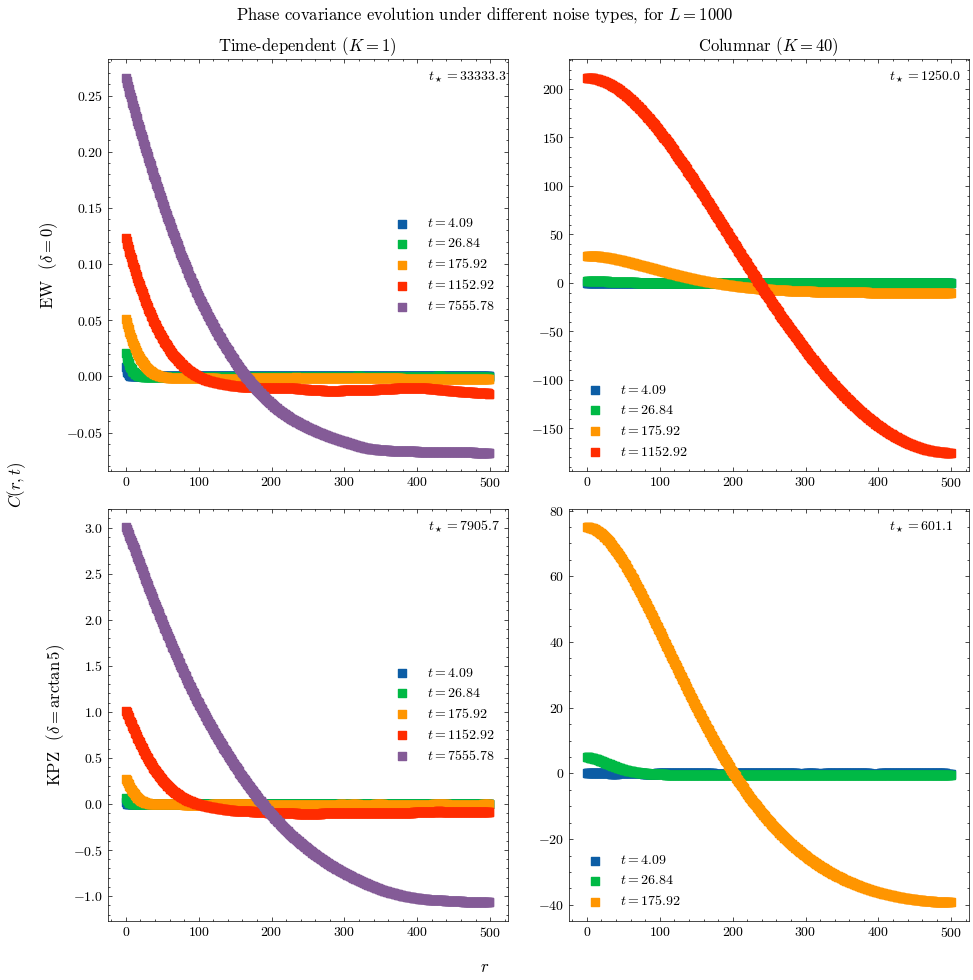

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(10,10))
fig.suptitle("Phase covariance evolution under different noise types, for $L=$" + str(L))

fig.supxlabel(r"$r$")
fig.supylabel(r"$C(r,t)$")

for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent", "Columnar"])):

    for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):

        # select rows for this noise type and delta
        mask = mask = (
            (avg_df["typenoise"] == typenoise)
            & (avg_df["L"] == L)
            & (avg_df["T"] == T)
            & (avg_df["deltaname"] == deltaname)
            & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
        )
        sub = avg_df[mask]

        # in case there are multiple (K, L) combos, plot them all
        for _, row in sub.iterrows():
            t = row["t"]            
            mean_phasecovariance = row["mean_phasecovariance"]
            L = row["L"]
            K = row["K"]
            M = row["M"]

            t_cross = tx[typenoise][delta_to_label[deltaname]] * L**(z_dict[typenoise][delta_to_label[deltaname]])

            for ti in range(mean_phasecovariance.shape[0])[::4]:

                if t[ti] > 0 and t[ti] < t_cross:
                    rlen = mean_phasecovariance.shape[1] # we plot up to half of this since the system is periodic
                    rrange = np.array(range(rlen))
                    ax[j,i].scatter(rrange[:int(rlen/2)], mean_phasecovariance[ti,:int(rlen/2)], label=f"$t=${np.round(t[ti],2)}", marker=markerdict[L])
                
            ax[j,i].text(0.8, 0.95, f'$t_\star={np.round(t_cross,1)}$', fontsize=10, transform=ax[j,i].transAxes)

ax[0,0].set_title(f"Time-dependent ($K=${Ks[0]})")
ax[0,1].set_title(f"Columnar ($K=${Ks[1]})")    
ax[0,0].set_ylabel(r"EW  ($\delta=0$)", fontsize=12)
ax[1,0].set_ylabel(r"KPZ  ($\delta=\arctan5$)", fontsize=12)

ax[0,0].legend()
ax[0,1].legend()
ax[1,0].legend()
ax[1,1].legend()

plt.tight_layout()
plt.show()

### Family-Vicsek collapse of the phase covariance (TO BE DONE)

We need constants $a_1$, $a_2$, which are fit assuming the functional form.

In [136]:
with open("airy_1_values.txt", 'r') as f:
    Airy_1 = {float(line.split(" ")[0]): float(line.split(" ")[1]) for line in f.readlines()}

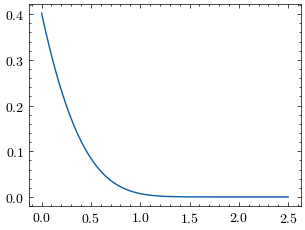

In [137]:
plt.plot(list(Airy_1.keys()), list(Airy_1.values()))

In [138]:
(0, Airy_1[0]), (0.5, Airy_1[0.5])

((0, 0.401945258645), (0.5, 0.084419174))

In [139]:
def covariance_constants(tti, C_Phi_t, beta, z, fun, x0=0.5):
    """ 
    Calculate the two "consntants" which are needed for the collapse of the covariance function,
    depending on the current time and the calculated covariance function at the current time C_Phi_t,
    adjusted to function fun = Airy_1 or Larkin.
    """

    a_1 = C_Phi_t[0] / (tti**(2*beta) * fun[0])  # Airy_1 function
    
    r_index = np.argmin(np.abs(C_Phi_t - a_1*tti**(2*beta)*fun[x0]))
    if fun[x0] < C_Phi_t[r_index]:
        r_other_index = r_index + 1
    else:
        r_other_index = r_index - 1
        
    slope = (r_index - r_other_index) / (C_Phi_t[r_index] - C_Phi_t[r_other_index])
    r_intermediate = (a_1 * fun[x0] * tti**(2*beta) - C_Phi_t[r_index]) / slope + r_index

    a_2 = r_intermediate / (tti**(1/z) * x0)  

    return a_1, a_2

<>:61: SyntaxWarning: invalid escape sequence '\s'
<>:61: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_39143/2162975800.py:61: SyntaxWarning: invalid escape sequence '\s'
  ax[1].text(0.8, 0.95, f'$t_\star={np.round(t_cross,1)}$', fontsize=10, transform=ax[1].transAxes)


2 0.5 0.25
15
0.009165297013930129 3.5017864352484347


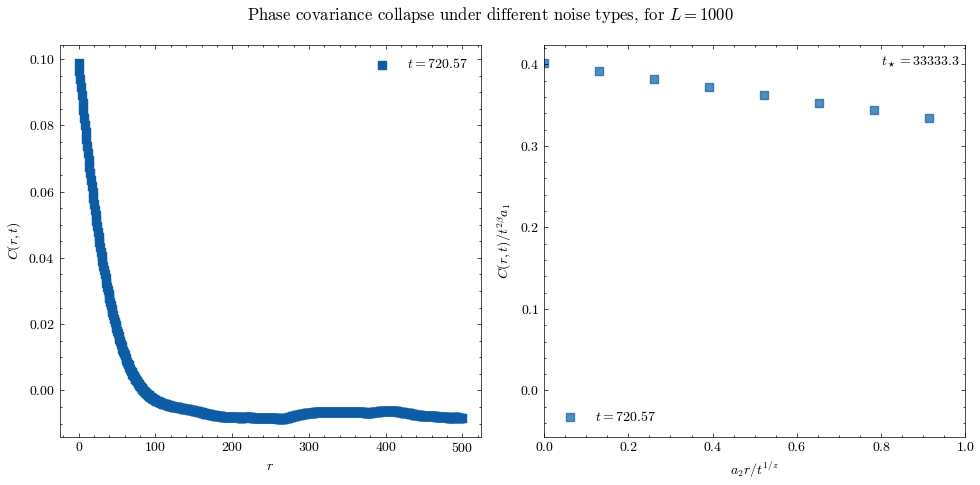

In [142]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle("Phase covariance collapse under different noise types, for $L=$" + str(L))

ax[0].set_xlabel(r"$r$")
ax[1].set_xlabel(r"$a_2 r/ t^{1/z}$")
ax[0].set_ylabel(r"$C(r,t)$")
ax[1].set_ylabel(r"$C(r,t)/ t^{2\beta} a_1$")

typenoise, typelabel = "TimeDep", "Time-dependent"

deltaname = "0"

# select rows for this noise type and delta
mask = mask = (
    (avg_df["typenoise"] == typenoise)
    & (avg_df["L"] == L)
    & (avg_df["T"] == T)
    & (avg_df["deltaname"] == deltaname)
    & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
)
sub = avg_df[mask]

# in case there are multiple (K, L) combos, plot them all
for _, row in sub.iterrows():
    t = row["t"]
    mean_phasecovariance = row["mean_phasecovariance"]
    L = row["L"]
    K = row["K"]
    M = row["M"]

    # Exponents
    z = z_dict[typenoise][delta_to_label[deltaname]]
    alpha = alpha_dict[typenoise][delta_to_label[deltaname]]
    beta = beta_dict[typenoise][delta_to_label[deltaname]]
    
    print(z, alpha, beta)

    t_cross = tx[typenoise][delta_to_label[deltaname]] * L**(z_dict[typenoise][delta_to_label[deltaname]])

    for ti in range(len(t))[::15]:

        if t[ti] > 0 and t[ti] < t_cross:

            print(ti)

            rlen = mean_phasecovariance.shape[1] # we plot up to half of this since the system is periodic
            rrange = np.array(range(rlen))

            ax[0].scatter(rrange[:int(rlen/2)], mean_phasecovariance[ti,:int(rlen/2)], label=f"$t=${np.round(t[ti],2)}", marker=markerdict[L])

            a_1, a_2 = covariance_constants(t[ti], mean_phasecovariance[ti,:], beta, z, fun=Airy_1) 
            
            print(a_1, a_2)

            # Collapse variables
            a2rt1z = rrange[:int(rlen/2)] * a_2 / t[ti]**(1/z)
            Ct2ba1 = mean_phasecovariance[ti,:int(rlen/2)] / (a_1 * t[ti]**(2*beta))

            ax[1].scatter(a2rt1z, Ct2ba1, label=f"$t=${np.round(t[ti],2)}", marker=markerdict[L], alpha=0.7)
            
    ax[1].text(0.8, 0.95, f'$t_\star={np.round(t_cross,1)}$', fontsize=10, transform=ax[1].transAxes)

ax[1].set_xlim(0,1)

ax[0].legend()
ax[1].legend()

plt.tight_layout()
plt.show()

In [143]:
0.74*216*(700)**(2/3)

12601.362284707418

In [144]:
tti = t[ti]
C_Phi_t = mean_phasecovariance[ti,:]
print(z, alpha, beta, tti, C_Phi_t.shape)

2 0.5 0.25 720.5703602851802 (1000,)


In [145]:
a_1, a_2 = covariance_constants(tti, C_Phi_t, beta, z, fun="Airy_1")
a_1, a_2

TypeError: can't multiply sequence by non-int of type 'numpy.float64'

In [146]:
a_1 = C_Phi_t[0] / (tti**(2*beta) * airy(0)[0])
a_1

np.float64(0.01037649740205166)

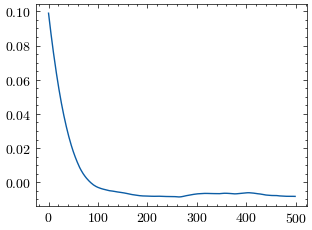

In [147]:
plt.plot(C_Phi_t[:500])

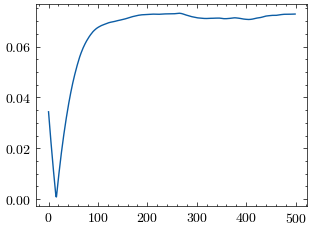

In [148]:
plt.plot(np.abs(C_Phi_t[:500] - a_1*tti**(2*beta)*airy(0.5)[0]))

In [149]:
r_index = np.argmin(np.abs(C_Phi_t - a_1*tti**(2*beta)*airy(0.5)[0]))
r_index, C_Phi_t[r_index-1:r_index+2], a_1*tti**(2*beta)*airy(0.5)[0], C_Phi_t[r_index] < a_1*tti**(2*beta)*airy(0.5)[0]

(np.int64(16),
 array([0.06557796, 0.06364971, 0.06175935]),
 np.float64(0.06453614629261918),
 np.True_)

Since $C_\phi[r_i]=0.06364$ is smaller than the value we want ($a_1 t^{2\beta}\mathcal{C}(0.5)=0.06453$) and $C_\phi[r]$ is decreasing, we take the PREVIOUS one and average them. 

In [150]:
r_other_index = r_index - 1
slope = (r_index - r_other_index) / (C_Phi_t[r_index] - C_Phi_t[r_other_index])
r_intermediate = (a_1 * airy(0.5)[0] * tti**(2*beta) - C_Phi_t[r_index]) / slope + r_index
print(slope, r_other_index, r_intermediate, r_index)

-518.6066185965481 15 15.999998290740091 16


In [151]:
a_2 = 0.5 * tti**(1/z) / r_intermediate
a_2

np.float64(0.8388576415655684)

In [152]:
a_1_dict

{'TimeDep': {'0': [np.float64(0.011210253911197381),
   np.float64(0.011074156012303904),
   np.float64(0.010870782242449294),
   np.float64(0.010221294884706411),
   np.float64(0.00860956465743786)],
  'atan5': [np.float64(0.02076361633621143),
   np.float64(0.02123489326556216),
   np.float64(0.024688452918653462),
   np.float64(0.02589736289293678),
   np.float64(0.021966104551636022)]},
 'Columnar': {'0': [np.float64(0.04428155077927755),
   np.float64(0.04119973622422899),
   np.float64(0.03384752784258198),
   np.float64(0.015216167125666666)],
  'atan5': [np.float64(0.08839003477622699),
   np.float64(0.0784506392521731),
   np.float64(0.06184912936666503)]}}

<>:64: SyntaxWarning: invalid escape sequence '\s'
<>:64: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_39143/3327332710.py:64: SyntaxWarning: invalid escape sequence '\s'
  ax[j,i].text(0.8, 0.95, f'$t_\star={np.round(t_cross,1)}$', fontsize=10, transform=ax[j,i].transAxes)


0.009901732994929573 984.9803612275209
0.00978152117219217 3.8604562057706144
0.009601886278707627 3.7697476995056283
0.009028210566195117 3.4163180299255917
0.007604610128891037 2.576963427073257
0.018339975757816127 1.5640231048020319
0.018756242718231727 221.9888978764752
0.02180668437975509 62.55536142585662
0.022874483902859913 1.0004452618746327
0.019402103104172716 0.6856216227790997
0.039112770851680814 27.69021055258316
0.03639068220804196 360.1806338096665
0.02989666299181029 130.13376073619855
0.013440054549886945 47.21398919078841
0.07807267620339355 10.649357422134488
0.06929346019367626 9.612534259347546
0.05462976751542304 37.48523625913443


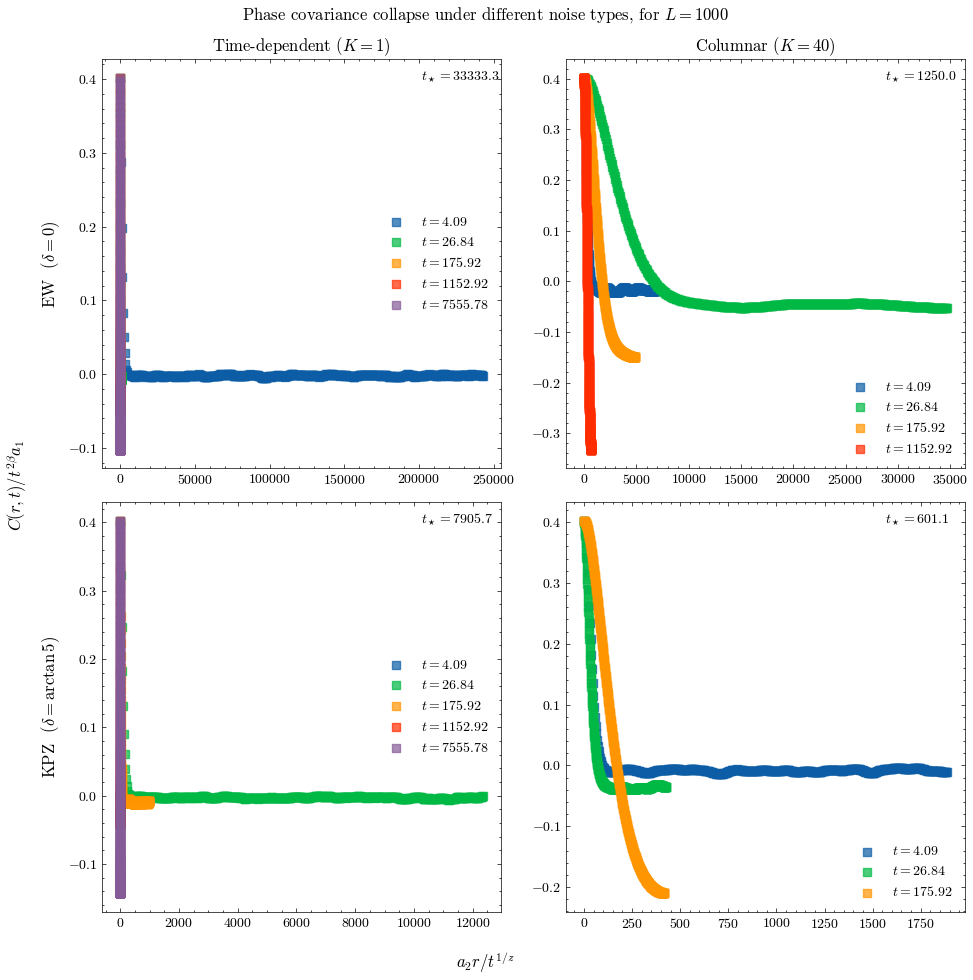

In [155]:
fig, ax = plt.subplots(2, 2, figsize=(10,10))
fig.suptitle("Phase covariance collapse under different noise types, for $L=$" + str(L))

fig.supxlabel(r"$a_2 r/ t^{1/z}$")
fig.supylabel(r"$C(r,t)/ t^{2\beta} a_1$")

a_1_dict = {}
a_2_dict = {}

for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent", "Columnar"])
):

    a_1_dict[typenoise] = {}
    a_2_dict[typenoise] = {}

    for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):

        a_1_dict[typenoise][deltaname] = []
        a_2_dict[typenoise][deltaname] = []
        
        # select rows for this noise type and delta
        mask = mask = (
            (avg_df["typenoise"] == typenoise)
            & (avg_df["L"] == L)
            & (avg_df["T"] == T)
            & (avg_df["deltaname"] == deltaname)
            & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
        )
        sub = avg_df[mask]

        # in case there are multiple (K, L) combos, plot them all
        for _, row in sub.iterrows():
            t = row["t"]
            mean_phasecovariance = row["mean_phasecovariance"]
            L = row["L"]
            K = row["K"]
            M = row["M"]

            # Exponents
            z = z_dict[typenoise][delta_to_label[deltaname]]
            alpha = alpha_dict[typenoise][delta_to_label[deltaname]]
            beta = beta_dict[typenoise][delta_to_label[deltaname]]
        
            t_cross = tx[typenoise][delta_to_label[deltaname]] * L**(z_dict[typenoise][delta_to_label[deltaname]])

            for ti in range(len(t))[::4]:

                if t[ti] > 0 and t[ti] < t_cross:

                    rlen = mean_phasecovariance.shape[1] # we plot up to half of this since the system is periodic
                    rrange = np.array(range(rlen))

                    a_1, a_2 = covariance_constants(t[ti], mean_phasecovariance[ti,:], beta, z, fun=Airy_1) 
                    print(a_1, a_2)
                    a_1_dict[typenoise][deltaname].append(a_1)
                    a_2_dict[typenoise][deltaname].append(a_2)

                    # Collapse variables
                    a2rt1z = rrange[:int(rlen/2)] * a_2 / t[ti]**(1/z_dict[typenoise][delta_to_label[deltaname]])
                    Ct2ba1 = mean_phasecovariance[ti,:int(rlen/2)] / (a_1 * t[ti]**(2*beta_dict[typenoise][delta_to_label[deltaname]]))

                    ax[j,i].scatter(a2rt1z, Ct2ba1, label=f"$t=${np.round(t[ti],2)}", marker=markerdict[L], alpha=0.7)
                    
            ax[j,i].text(0.8, 0.95, f'$t_\star={np.round(t_cross,1)}$', fontsize=10, transform=ax[j,i].transAxes)


# ax[0,0].set_xlim(0,1)
# ax[0,1].set_xlim(0,1)
# ax[1,0].set_xlim(0,1)
# ax[1,1].set_xlim(0,1)

ax[0,0].set_title(f"Time-dependent ($K=${Ks[0]})")
ax[0,1].set_title(f"Columnar ($K=${Ks[1]})")     
ax[0,0].set_ylabel(r"EW  ($\delta=0$)", fontsize=12)
ax[1,0].set_ylabel(r"KPZ  ($\delta=\arctan5$)", fontsize=12)

ax[0,0].legend()
ax[0,1].legend()
ax[1,0].legend()
ax[1,1].legend()

plt.tight_layout()
plt.show()

<>:64: SyntaxWarning: invalid escape sequence '\s'
<>:64: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_39143/2434035693.py:64: SyntaxWarning: invalid escape sequence '\s'
  ax[j,i].text(0.8, 0.95, f'$t_\star={np.round(t_cross,1)}$', fontsize=10, transform=ax[j,i].transAxes)


0.009901732994929573 984.9803612275209
0.00978152117219217 3.8604562057706144
0.009601886278707627 3.7697476995056283
0.009028210566195117 3.4163180299255917
0.007604610128891037 2.576963427073257
0.018339975757816127 1.5640231048020319
0.018756242718231727 221.9888978764752
0.02180668437975509 62.55536142585662
0.022874483902859913 1.0004452618746327
0.019402103104172716 0.6856216227790997
0.039112770851680814 27.69021055258316
0.03639068220804196 360.1806338096665
0.02989666299181029 130.13376073619855
0.013440054549886945 47.21398919078841
0.07807267620339355 10.649357422134488
0.06929346019367626 9.612534259347546
0.05462976751542304 37.48523625913443


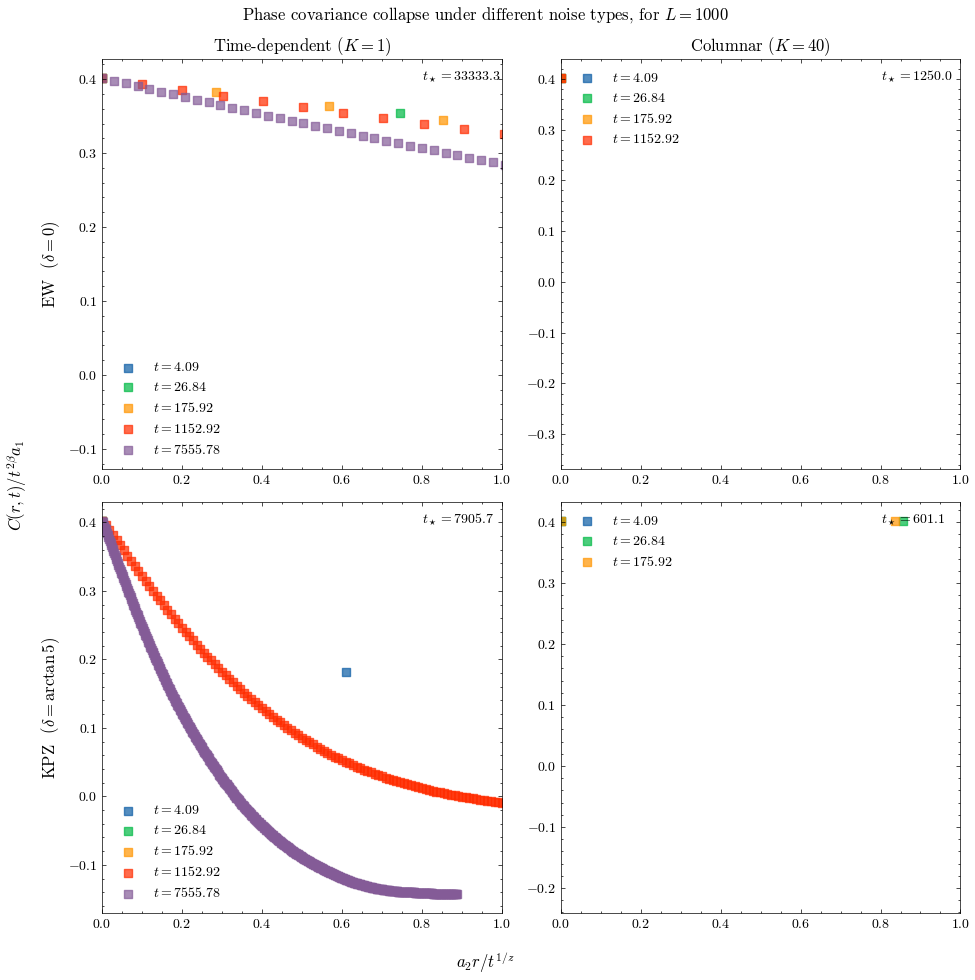

In [156]:
fig, ax = plt.subplots(2, 2, figsize=(10,10))
fig.suptitle("Phase covariance collapse under different noise types, for $L=$" + str(L))

fig.supxlabel(r"$a_2 r/ t^{1/z}$")
fig.supylabel(r"$C(r,t)/ t^{2\beta} a_1$")

a_1_dict = {}
a_2_dict = {}

for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent", "Columnar"])
):

    a_1_dict[typenoise] = {}
    a_2_dict[typenoise] = {}

    for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):

        a_1_dict[typenoise][deltaname] = []
        a_2_dict[typenoise][deltaname] = []
        
        # select rows for this noise type and delta
        mask = mask = (
            (avg_df["typenoise"] == typenoise)
            & (avg_df["L"] == L)
            & (avg_df["T"] == T)
            & (avg_df["deltaname"] == deltaname)
            & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
        )
        sub = avg_df[mask]

        # in case there are multiple (K, L) combos, plot them all
        for _, row in sub.iterrows():
            t = row["t"]
            mean_phasecovariance = row["mean_phasecovariance"]
            L = row["L"]
            K = row["K"]
            M = row["M"]

            # Exponents
            z = z_dict[typenoise][delta_to_label[deltaname]]
            alpha = alpha_dict[typenoise][delta_to_label[deltaname]]
            beta = beta_dict[typenoise][delta_to_label[deltaname]]
        
            t_cross = tx[typenoise][delta_to_label[deltaname]] * L**(z_dict[typenoise][delta_to_label[deltaname]])

            for ti in range(len(t))[::4]:

                if t[ti] > 0 and t[ti] < t_cross:

                    rlen = mean_phasecovariance.shape[1] # we plot up to half of this since the system is periodic
                    rrange = np.array(range(rlen))

                    a_1, a_2 = covariance_constants(t[ti], mean_phasecovariance[ti,:], beta, z, fun=Airy_1) 
                    print(a_1, a_2)
                    a_1_dict[typenoise][deltaname].append(a_1)
                    a_2_dict[typenoise][deltaname].append(a_2)

                    # Collapse variables
                    a2rt1z = rrange[:int(rlen/2)] * a_2 / t[ti]**(1/z_dict[typenoise][delta_to_label[deltaname]])
                    Ct2ba1 = mean_phasecovariance[ti,:int(rlen/2)] / (a_1 * t[ti]**(2*beta_dict[typenoise][delta_to_label[deltaname]]))

                    ax[j,i].scatter(a2rt1z, Ct2ba1, label=f"$t=${np.round(t[ti],2)}", marker=markerdict[L], alpha=0.7)
                    
            ax[j,i].text(0.8, 0.95, f'$t_\star={np.round(t_cross,1)}$', fontsize=10, transform=ax[j,i].transAxes)


ax[0,0].set_xlim(0,1)
ax[0,1].set_xlim(0,1)
ax[1,0].set_xlim(0,1)
ax[1,1].set_xlim(0,1)

ax[0,0].set_title(f"Time-dependent ($K=${Ks[0]})")
ax[0,1].set_title(f"Columnar ($K=${Ks[1]})")     
ax[0,0].set_ylabel(r"EW  ($\delta=0$)", fontsize=12)
ax[1,0].set_ylabel(r"KPZ  ($\delta=\arctan5$)", fontsize=12)

ax[0,0].legend()
ax[0,1].legend()
ax[1,0].legend()
ax[1,1].legend()

plt.tight_layout()
plt.show()

In [60]:
a_1_dict, a_2_dict

({'TimeDep': {'0': [np.float64(0.011210253911197381),
    np.float64(0.011074156012303904),
    np.float64(0.010870782242449294),
    np.float64(0.010221294884706411),
    np.float64(0.00860956465743786)],
   'atan5': [np.float64(0.02076361633621143),
    np.float64(0.02123489326556216),
    np.float64(0.024688452918653462),
    np.float64(0.02589736289293678),
    np.float64(0.021966104551636022)]},
  'Columnar': {'0': [np.float64(0.04428155077927755),
    np.float64(0.04119973622422899),
    np.float64(0.03384752784258198),
    np.float64(0.015216167125666666)],
   'atan5': [np.float64(0.08839003477622699),
    np.float64(0.0784506392521731),
    np.float64(0.06184912936666503)]}},
 {'TimeDep': {'0': [np.float64(0.0010124866723993935),
    np.float64(0.8091209559613236),
    np.float64(0.8229258716944665),
    np.float64(0.8722964463309322),
    np.float64(1.0589626990684675)],
   'atan5': [np.float64(2.0175446514661872),
    np.float64(0.0044901533528841475),
    np.float64(0.015793